<a href="https://colab.research.google.com/github/Fauzi455/PCVK26_12_M-Fauzi-R/blob/main/P2_Tugas%20D1_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#D1. Pengenalan Python: Pengolahan Citra Dasar dan memahami channel warna pada OpenCV dan konversinya

1. Membuat koneksi antara Colab dengan Google Drive agar bisa
mengakses file di dalamnya.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#mengakses gambar dengan fungsi upload file

from google.colab import files
uploaded = files.upload()

Saving KTP TUHAN.jpeg to KTP TUHAN.jpeg


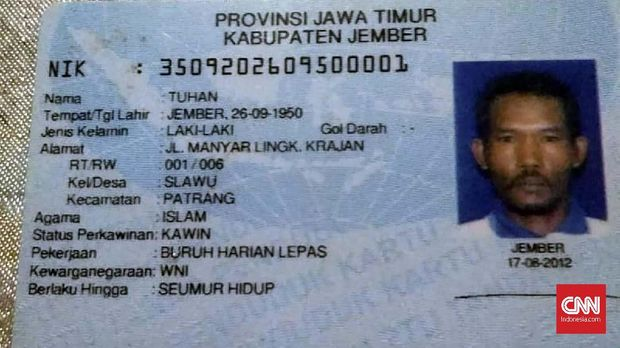

Resolusi gambar:  620  x  348


In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('KTP TUHAN.jpeg')
cv2_imshow(img)

print("Resolusi gambar: ", img.shape[1], " x ", img.shape[0])

2. Menampilkan Gambar

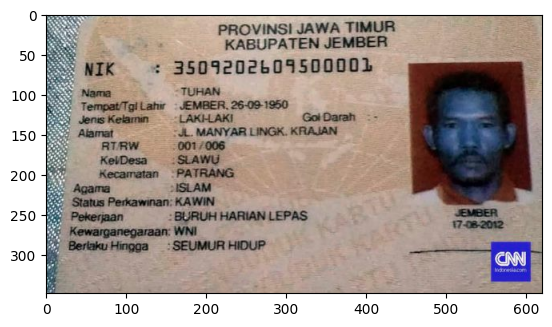

In [5]:
img = cv.imread('KTP TUHAN.jpeg')
plt.imshow(img)

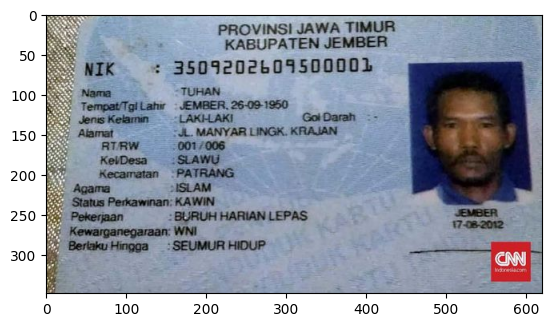

In [6]:
img = cv.imread('KTP TUHAN.jpeg')
img2 = cv.cvtColor(img, cv.COLOR_BGR2RGB) #konversi channel BGR -> RGB
plt.imshow(img2)

3. Menampilkan citra Grayscale:

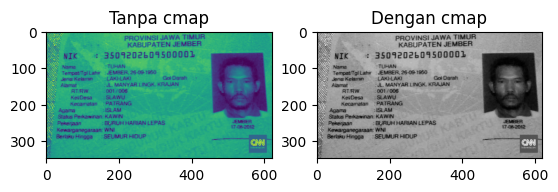

In [7]:
img_gray = cv.imread('KTP TUHAN.jpeg', cv.IMREAD_GRAYSCALE)

#tanpa cmap
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

#dengan cmap
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap')

plt.show()

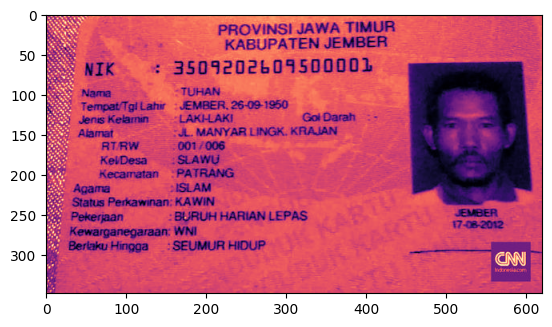

In [8]:
plt.imshow(img_gray, cmap='magma')

4. Melakukan resizing

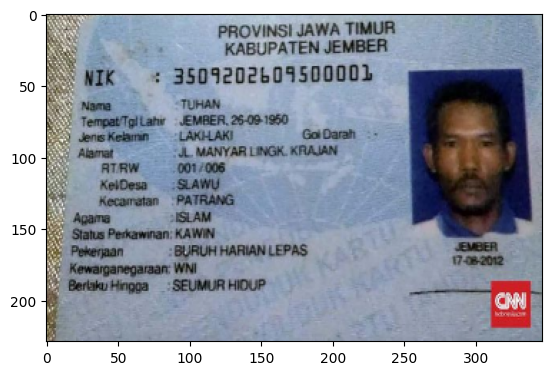

In [9]:
imgRGB = cv.cvtColor(img,cv.COLOR_BGR2RGB) #konversi BGR ke RGB
img_output = cv.resize(imgRGB, (347,229))
plt.imshow(img_output)

5. Melakukan Flipping

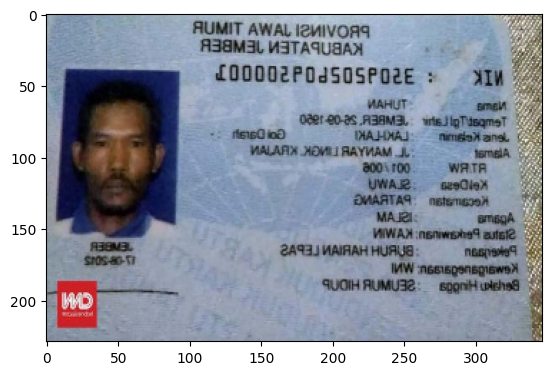

In [10]:
imgFlip = cv.flip(img_output,1)
plt.imshow(imgFlip)

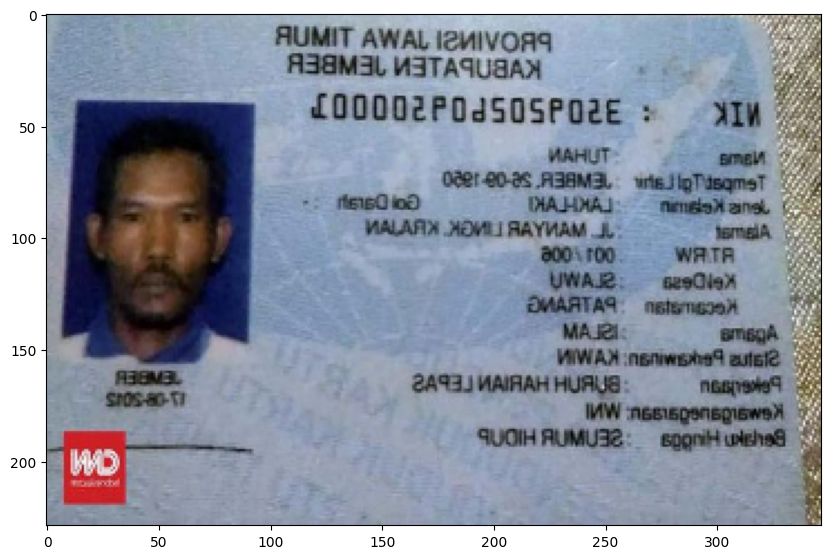

In [11]:
imgFlip = cv.flip(img_output,1)

#tampilkan ukuran canvas yang lebih besar
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1)
ax.imshow(imgFlip)

6. Membuat bentuk Geometri 2D dari OpenCV. Diawali dengan pembuatan black image dengan tipe data int16

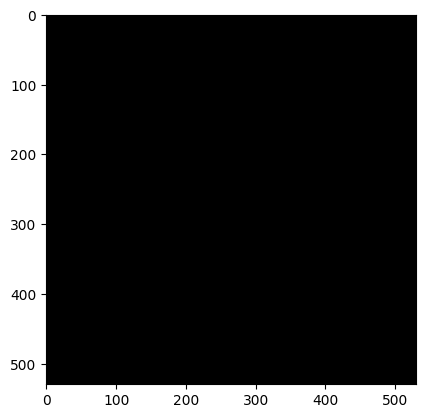

In [12]:
black_img = np.zeros((530,530,3), dtype=np.int16)
plt.imshow(black_img)

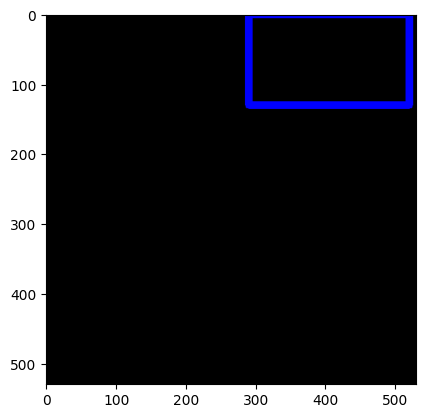

In [13]:
#perhatikan koordinat titik2 pt1 dan pt2
cv.rectangle(black_img,pt1=(290,0),pt2=(520,130),color=(0,0,255),thickness=10)
plt.imshow(black_img)

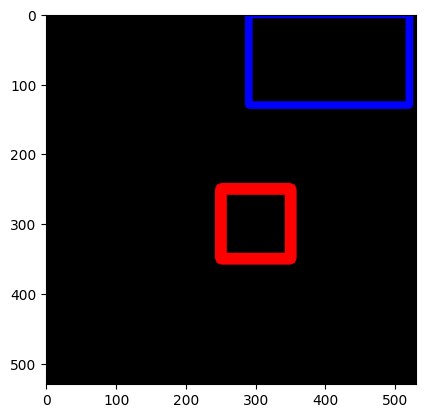

In [14]:
cv.rectangle(black_img,pt1=(250,250),pt2=(350,350),color=(255,0,0),thickness=15)
plt.imshow(black_img)

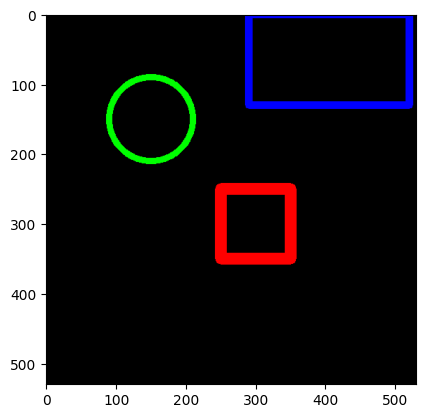

In [15]:
cv.circle(black_img,center=(150,150),radius=60,color=(0,255,0),thickness=8)
plt.imshow(black_img)

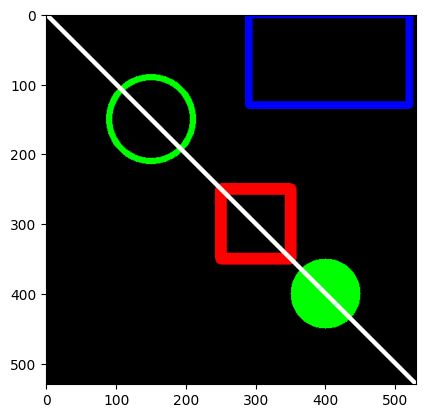

In [16]:
cv.circle(black_img,center=(400,400),radius=50,color=(0,255,0),thickness=-1)
cv.line(black_img,pt1=(0,0),pt2=(530,530),color=(255,255,255),thickness=5)
plt.imshow(black_img)

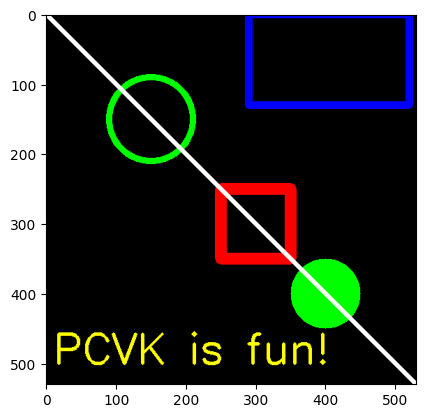

In [17]:
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img,text='PCVK is fun!',org=(10,500),fontFace=font,fontScale=2,
           color=(255,255,0),thickness=3,lineType=cv.LINE_AA)
plt.imshow(black_img)

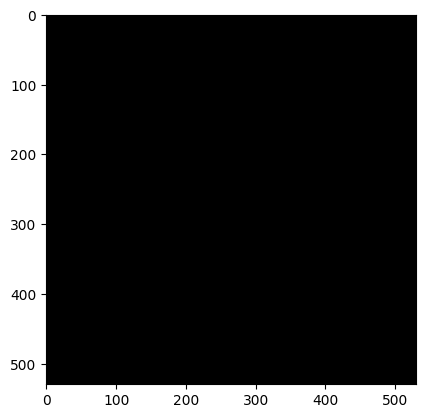

In [18]:
black_img2 = np.zeros((530,530,3), dtype=np.int32)
plt.imshow(black_img2)

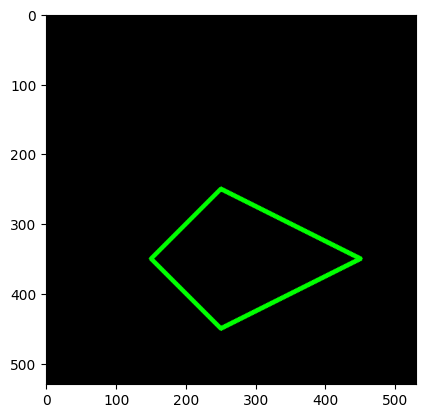

In [19]:
vertices = np.array([[150,350],[250,250],[450,350],[250,450]],dtype=np.int32)
pts = vertices.reshape((-1,1,2)) #nilai 2 untuk menunjukkan bahwa tiap titik dibuat 3 channel yang mewakili R, G, dan B
cv.polylines(black_img2,[pts],isClosed=True,color=(0,255,0),thickness=5)
plt.imshow(black_img2)

#PERTANYAAN PRAKTIKUM

1. Tampilkan satu citra bebas menggunakan cv2_imshow() dan plt.imshow()
tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan
mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut.

    Jawab : Karena OpenCV membaca citra dalam format warna BGR (Blue, Green, Red), sedangkan Matplotlib membaca citra dalam format RGB (Red, Green, Blue)

Tampilan cv2_imshow():


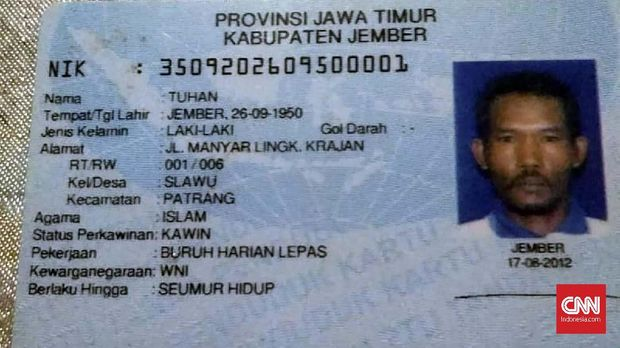

Tampilan plt.imshow():


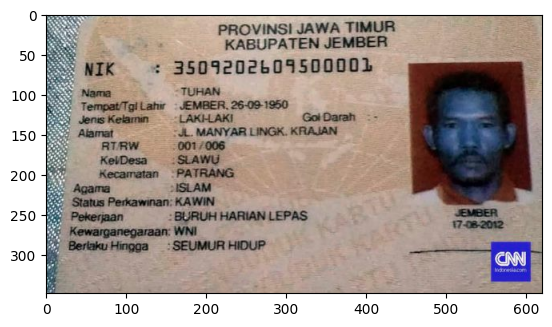

In [22]:
img = cv2.imread('KTP TUHAN.jpeg')

print("Tampilan cv2_imshow():")
cv2_imshow(img)

print("Tampilan plt.imshow():")
plt.imshow(img)
plt.show()

2. Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32.
Bandingkan dtype, min(), max(), dan nbytes keduanya. Apakah tampilannya
berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.

    Jawab : Ya, berbeda. Karena tipe data int16 menggunakan 16bit (2 byte) per piksel, sedangkan int32 menggunakan 32bit (4 byte) per piksel. Sehingga nbytes dari int32 tepat dua kali lebih besar daripada int16

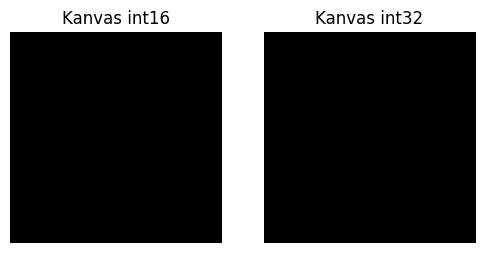

--- Hasil Perbandingan Properti ---
int16 -> dtype: int16 | min: 0 | max: 0 | nbytes: 80000 bytes
int32 -> dtype: int32 | min: 0 | max: 0 | nbytes: 160000 bytes


In [27]:
import numpy as np

#buat kanvas hitam berukuran sama
img_int16 = np.zeros((200, 200), dtype=np.int16)
img_int32 = np.zeros((200, 200), dtype=np.int32)

# Alternatif: Menampilkan berdampingan menggunakan Matplotlib
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img_int16, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Kanvas int16")
axes[0].axis('off')

axes[1].imshow(img_int32, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Kanvas int32")
axes[1].axis('off')
plt.show()

# 3. Cetak perbandingan nilai/properti
print("--- Hasil Perbandingan Properti ---")
print("int16 -> dtype:", img_int16.dtype, "| min:", img_int16.min(), "| max:", img_int16.max(), "| nbytes:", img_int16.nbytes, "bytes")
print("int32 -> dtype:", img_int32.dtype, "| min:", img_int32.min(), "| max:", img_int32.max(), "| nbytes:", img_int32.nbytes, "bytes")

3. Apa kegunaan baris from google.colab.patches import cv2_imshow, dan
mengapa cv2.imshow() bawaan OpenCV tidak dapat dipakai di Google Colab?

    Jawab : cv2_imshow merupakan fungsi pengganti bawaan dari Google Colab untuk cv2.imshow milik OpenCV yang dimana fungsinya untuk merender citra agar tampil langsung di dalam notebook. Dan cv2.imshow() milik OpenCV tidak dapat dipakai di Google Colab karena Google colab berjalan di server dan tidak memiliki GUI/layar monitor, sehingga membutuhkan cv_imshow untuk menampilkannya

4. Citra yang dibaca dengan skimage.io.imread() ditampilkan berdampingan
dengan hasil cv2.cvtColor(img, cv2.COLOR_BGR2RGB) atas citra yang
sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang
kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan
visual saja.

    Jawab : skimage.io.imread() membaca citra langsung kedalam format RGB. Sedangkan cv2.imread() membaca citra dalam BGR, namun jika ditambahkan cv2.cvtColor(img, cv2.COLOR_BGR2RGB), maka urutan warna dikembalikan menjadi RGB.

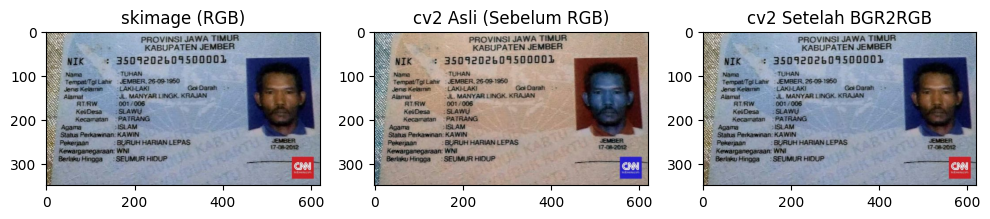

Nilai piksel skimage (RGB) : [129 127 106]
Nilai piksel cv2 (BGR)     : [106 127 129]
Nilai piksel cv2 (RGB)     : [129 127 106]


In [8]:
import cv2
import matplotlib.pyplot as plt
from skimage import io

path = 'KTP TUHAN.jpeg'

# 1. Baca gambar
img_skimage = io.imread(path) # Format RGB
img_cv2_bgr = cv2.imread(path) # Format BGR
img_cv2_rgb = cv2.cvtColor(img_cv2_bgr, cv2.COLOR_BGR2RGB) # Format setelah BGR -> RGB

# 2. Tampilkan 3 gambar berdampingan
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_skimage)
axes[0].set_title("skimage (RGB)")

axes[1].imshow(img_cv2_bgr)
axes[1].set_title("cv2 Asli (Sebelum RGB)")

axes[2].imshow(img_cv2_rgb)
axes[2].set_title("cv2 Setelah BGR2RGB")

plt.show()

# 3. Bukti nilai piksel
print("Nilai piksel skimage (RGB) :", img_skimage[0, 0])
print("Nilai piksel cv2 (BGR)     :", img_cv2_bgr[0, 0])
print("Nilai piksel cv2 (RGB)     :", img_cv2_rgb[0, 0])

5. Setelah citra ditampilkan dengan figsize yang jauh lebih besar, apakah nilai
img.shape ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra
dan mengubah ukuran tampilan.

    Jawab : figsize hanya mengatur besar kecilnya gambar yang digambar pada layar notebook sehingga tidak merubah nilai img.shape. Sedangkan cv2.resize() memproses ulang data gambar dengan cara menambah atau memotong baris dan kolom pikselnya